<a href="https://colab.research.google.com/github/saradom11/Simulaci-n-I/blob/main/Variables_antiteticas_para_estimaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Variables antitéticas:**

Queremos estimar \
$$I=\int^1_0 e^{x^2} dx $$

Para variables antitéticas usamos:
$$ f(U),f(1−U) $$
para reducir varianza

Con un estimador:
$$I≈\frac{1}{n} ​∑\frac{f(U_i​)+f(1−U_i​)}{2}​$$

El método de variables antitéticas es una técnica de reducción de varianza diseñada para hacer que las simulaciones de Monte Carlo sean más eficientes. Su objetivo principal es lograr estimaciones confiables utilizando menos iteraciones computacionales.

Integral = 1.4611569948010803
Simulaciones = 265
Desviacion = 0.16255736403009272


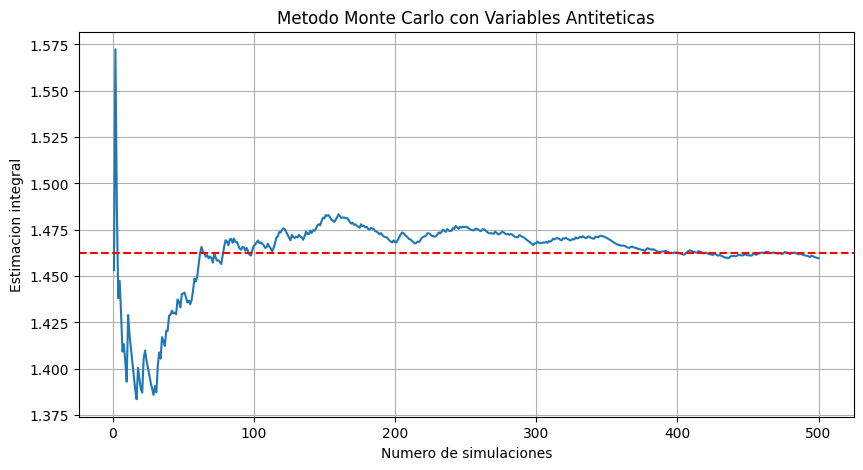

In [6]:
#Importamos las librerías
import numpy as np
import random as r
import matplotlib.pyplot as plt

def f(x):
    return np.exp(x**2)   #Definimos la función

def mc_antitetico(tolerancia, minimo): #Función para el método de variables antitéticas

    n =0
    resultados =[]

    while True:
        U =r.random()   #generamos U
        Y =(f(U)+f(1-U))/2   #variable antitetica
        resultados.append(Y)
        n +=1

        media =np.mean(resultados) #media
        s =np.std(resultados,ddof=1) #desviacion
        error =s/np.sqrt(n) #error

        if n>=minimo and error<tolerancia: #detener cuando cumpla la cindición
            break

    return media,n,s,error

I,n,s,error =mc_antitetico(0.01,100)
print("Integral =",I)
print("Simulaciones =",n)
print("Desviacion =",s)


def antitetico_grafica(N): #Hacemos una funcion para el proceso de la grafica

    estimaciones =[]   #Lista para guardar las estimaciones
    suma =0

    for i in range(1, N+1):
        U =r.random()
        Y =(f(U)+f(1-U))/2
        suma =suma+Y
        promedio =suma/i
        estimaciones.append(promedio)
    return estimaciones

N =500
estimaciones =antitetico_grafica(N)

valor_real =1.46265  #Resultado aproximado de la integral para la línea guía

plt.figure(figsize=(10,5))
plt.plot(range(1,N+1), estimaciones)
plt.axhline(valor_real, linestyle="--", color="red")
plt.xlabel("Numero de simulaciones")
plt.ylabel("Estimacion integral")
plt.title("Metodo Monte Carlo con Variables Antiteticas")
plt.grid()
plt.show()
